# 03 · The proprotor: momentum plus profile power, calibrated on JVX

The rotor is where a tiltrotor's two lives meet: a big, lightly loaded helicopter rotor in hover and a propeller in
cruise. This tutorial covers the rotor model in the sizing, its calibration on full-scale test data, how the
optimizer uses it, and its one big known weakness.

**What you will learn**
1. Momentum theory, figure of merit, and why a constant figure of merit cannot size a rotor.
2. `MomentumProfileRotor`: induced plus profile power, one drag polar for hover and cruise.
3. The least-squares calibration on the NASA JVX proprotor test.
4. Why the sized Halo rotor sits on a corner of its design space (tip-speed bound, solidity bound, blade-loading
   limit, rotor radius capped by the span).
5. The cruise pathology: with no blade stall, cruise rotor speed is set by validity bounds, not physics.

**Run time:** under a minute.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from examples.halo_sizing import HaloRequirements, build_halo_aircraft
from aircraft_closure.powertrain.components.rotor import MomentumProfileRotor, profile_integral
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor

ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
rotor = aircraft.powertrain.topology.instances["propulsor"].component      # the sized Halo rotor (numbers)
print(f"Halo rotor: radius {rotor.radius_m():.2f} m, disk {rotor.area_disk_m2:.1f} m2, solidity {rotor.solidity:.3f}, "
      f"design tip speed {rotor.speed_tip_max_m_s:.1f} m/s")

Halo rotor: radius 4.83 m, disk 73.4 m2, solidity 0.060, design tip speed 238.2 m/s


## 1. Momentum theory and the figure of merit

An ideal rotor producing thrust T from a disk of area A in still air needs the **ideal induced power**

$$P_{ideal} = \frac{T^{3/2}}{\sqrt{2\rho A}} \qquad (v_i = \sqrt{T / 2\rho A}).$$

The real rotor also pays non-uniform inflow, tip losses and blade profile drag. The **figure of merit**
FM = P_ideal / P_actual lumps all of that into one number (0.6-0.8 for good rotors). Disk loading T/A sets the ideal
power per unit thrust: big, lightly loaded rotors hover efficiently, which is the reason for a tiltrotor's huge
rotors.

In [2]:
from examples.halo_sizing import build_halo_aerodynamics
g = 9.80665
atm_hover = asb.Atmosphere(altitude=requirements.altitude_hover_m)
download = build_halo_aerodynamics(requirements, assumptions).hover_download_fraction(aircraft)   # tutorial 06
thrust_per_rotor_N = requirements.thrust_to_weight_hover * ref.mass_takeoff_kg * g / (1 - download) / 2
p_ideal_W = thrust_per_rotor_N**1.5 / np.sqrt(2 * atm_hover.density() * rotor.area_disk_m2)
print(f"hover download {download:.3f} of the thrust")
print(f"4,000 ft hover: thrust per rotor {thrust_per_rotor_N / 1e3:.1f} kN, disk loading "
      f"{thrust_per_rotor_N / rotor.area_disk_m2:.0f} N/m2, ideal power {p_ideal_W / 1e3:.0f} kW per rotor")

hover download 0.067 of the thrust
4,000 ft hover: thrust per rotor 38.0 kN, disk loading 518 N/m2, ideal power 587 kW per rotor


## 2. Two rotor models

**`ActuatorDiskPropulsor`** (`powertrain/components/propulsor.py`) is momentum theory with a constant FM (0.67,
calibrated on the XV-15 hover performance) and a constant airplane-mode efficiency factor. It is still in the code
as the simplest model (`HaloAssumptions(rotor_speed_physics=False)`), but it has a fatal blind spot for sizing:
**it cannot see rotor speed, solidity or tip speed**, so the optimizer cannot trade them.

**`MomentumProfileRotor`** (`powertrain/components/rotor.py`, the default since plan 016) writes the power
coefficient on the disk and tip speed (C_T = T / ρA(ΩR)², C_P = P / ρA(ΩR)³, advance ratio λ = V/ΩR, solidity σ) as
induced power plus profile power:

$$\text{hover:}\quad C_P = \kappa\, C_T \sqrt{C_T/2} + \frac{\sigma}{8}\, c_d\!\left(\tfrac{C_T}{\sigma}\right)$$

$$\text{airplane mode:}\quad C_P = C_T\lambda + \kappa\, C_T \lambda_i + \frac{\sigma}{2}\, c_d\!\left(\tfrac{C_T}{\sigma}, \lambda\right) I(\lambda),
\qquad \lambda_i = -\tfrac{\lambda}{2} + \sqrt{\tfrac{\lambda^2}{4} + \tfrac{C_T}{2}}$$

- κ = 1.15 is the induced-power factor (non-uniform inflow and tip loss), fixed.
- I(λ) = ∫₀¹ x² √(x² + λ²) dx is the profile-power integral over the blade in a helical flow (closed form in the
  code; I(0) = 1/4 recovers the hover term).
- The section drag is a **single polar** in the blade loading referred to the mean section dynamic pressure,
  x = (C_T/σ)/(1 + 3λ²): c_d = d₀ + d₁x + d₂x², plus an airplane-mode increment a + bλ² (twist off-design, hub and
  spinner).

Profile power scales like σ ρ A (ΩR)³ c_d: that is what makes solidity and tip speed real trades.

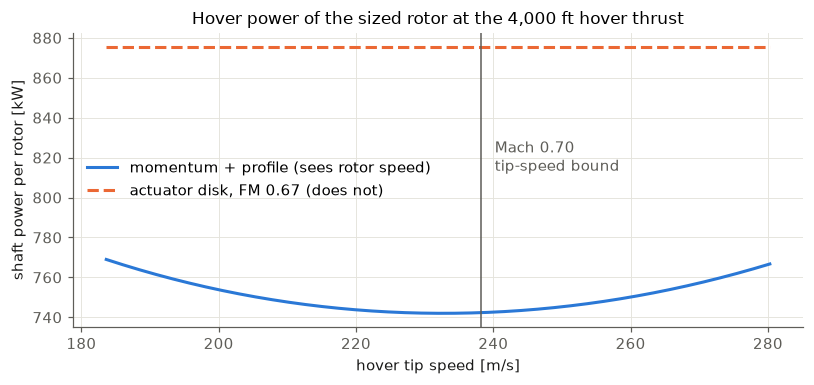

lowest hover power at 232 m/s tip speed; the sized rotor runs at 238 m/s
figure of merit of the sized rotor at its design tip speed: 0.790


In [3]:
actuator = ActuatorDiskPropulsor(area_disk_m2=rotor.area_disk_m2, coefficient_of_performance=0.67)
speeds = np.linspace(38, 58, 41)
p_mp = [float(rotor.evaluate(0.0, atm_hover, thrust_N=thrust_per_rotor_N, speed_rad_s=w).shaft_power_W) for w in speeds]
p_ad = [float(actuator.evaluate(0.0, atm_hover, thrust_N=thrust_per_rotor_N).shaft_power_W)] * len(speeds)
loading = [float(rotor.evaluate(0.0, atm_hover, thrust_N=thrust_per_rotor_N, speed_rad_s=w).blade_loading) for w in speeds]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(speeds * rotor.radius_m(), np.array(p_mp) / 1e3, color=blue, lw=2, label="momentum + profile (sees rotor speed)")
ax.plot(speeds * rotor.radius_m(), np.array(p_ad) / 1e3, color=orange, lw=2, ls="--", label="actuator disk, FM 0.67 (does not)")
ax.axvline(rotor.speed_tip_max_m_s, color=ink_muted, lw=1)
ax.text(rotor.speed_tip_max_m_s + 2, 820, "Mach 0.70\ntip-speed bound", ha="left", va="center", color=ink_muted)
ax.set(xlabel="hover tip speed [m/s]", ylabel="shaft power per rotor [kW]",
       title="Hover power of the sized rotor at the 4,000 ft hover thrust")
ax.legend(loc="center left"); plt.tight_layout(); plt.show()
best = speeds[int(np.argmin(p_mp))] * rotor.radius_m()
print(f"lowest hover power at {best:.0f} m/s tip speed; the sized rotor runs at {rotor.speed_tip_max_m_s:.0f} m/s")
fm_at_design = p_ideal_W / rotor.evaluate(0.0, atm_hover, thrust_N=thrust_per_rotor_N,
                                          speed_rad_s=rotor.speed_tip_max_m_s / rotor.radius_m()).shaft_power_W
print(f"figure of merit of the sized rotor at its design tip speed: {fm_at_design:.3f}")

At the high-tip-speed end the profile power ∝ (ΩR)³ rises; at the low end the blade loading C_T/σ rises and the
polar's d₂x² term makes the blades work harder. The figure of merit falls out of the model (0.79 here, at the design tip speed) instead of
being assumed. Notice the sized rotor runs a little *faster* than its lowest-power tip speed: section 4 explains
why (torque sizes the drive).

## 3. Calibration on the JVX proprotor

The constants are fitted to the full-scale **JVX** proprotor test (25 ft, 3 blades, σ = 0.1138), NASA/TM-2016-219070
(Acree 2016), digitized into `data/rotors/`:

- **hover**, Table D-1 (tip Mach 0.67-0.68): 58 points fit the polar (d₀, d₁, d₂); Table D-2 (tip Mach 0.73) is held
  out as a prediction check;
- **airplane mode**, Phase II NFAC 40×80 (λ 0.26-0.56): 42 points fit the increment (a, b).

The model is *linear in its drag coefficients*, so both fits are ordinary least squares (`examples/jvx_rotor_calibration.py`).
κ is not identifiable separately from the loading terms over this data (free fits give κ < 1, unphysical), so it is
fixed at 1.15.

In [4]:
from examples import jvx_rotor_calibration as jvx
report = jvx.calibration_report()
print(f"hover polar d0, d1, d2 = {tuple(round(float(v), 5) for v in report.polar)}")
print(f"airplane increment a, b = {tuple(round(float(v), 5) for v in report.increment)}")
print(f"hover FM rms error {report.hover_fm_rms:.4f}; held-out D-2 power error max {report.hover_d2_power_error_max:.4f}")
print(f"airplane efficiency rms error {report.airplane_eta_rms:.4f}, max {report.airplane_eta_max:.4f}")
check("the fit reproduces the constants built into MomentumProfileRotor",
      np.allclose(report.polar, MomentumProfileRotor(area_disk_m2=1.0, solidity=0.1).drag_polar))
check("hover figure of merit within 0.0125 rms", report.hover_fm_rms < 0.0125)
check("cruise efficiency within 0.013 rms", report.airplane_eta_rms < 0.013)

hover polar d0, d1, d2 = (0.0185, -0.22164, 1.06625)
airplane increment a, b = (0.00169, 0.01876)
hover FM rms error 0.0123; held-out D-2 power error max 0.0216
airplane efficiency rms error 0.0128, max 0.0363
PASS  the fit reproduces the constants built into MomentumProfileRotor
PASS  hover figure of merit within 0.0125 rms
PASS  cruise efficiency within 0.013 rms


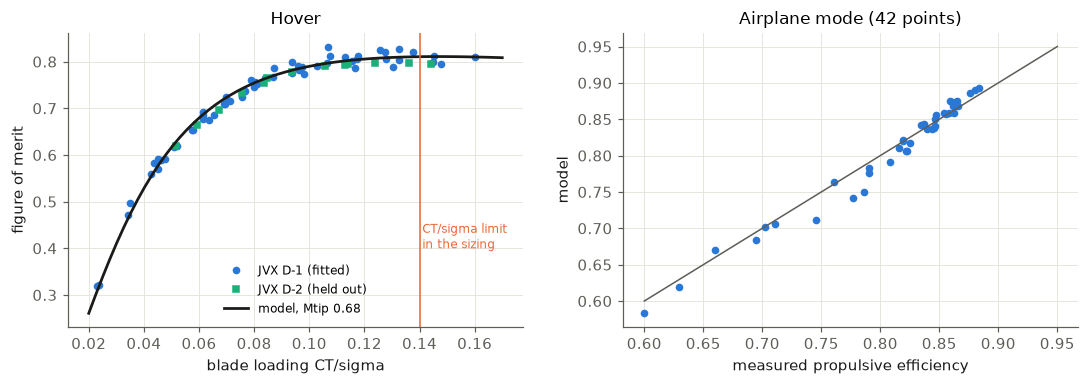

In [5]:
hover, airplane = jvx.load_hover(), jvx.load_airplane()
calibrated = jvx.jvx_rotor(report.polar, report.increment)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
d1 = np.array([t == "D-1" for t in hover.table])
axes[0].plot(hover.blade_loading[d1], hover.figure_of_merit[d1], "o", ms=4, color=blue, label="JVX D-1 (fitted)")
axes[0].plot(hover.blade_loading[~d1], hover.figure_of_merit[~d1], "s", ms=4, color=aqua, label="JVX D-2 (held out)")
loads = np.linspace(0.02, 0.17, 60)
axes[0].plot(loads, [jvx.predict(calibrated, x, 0.0, 0.68)[1] for x in loads], color=ink, lw=1.8, label="model, Mtip 0.68")
axes[0].axvline(0.14, color=orange, lw=1); axes[0].text(0.141, 0.4, "CT/sigma limit\nin the sizing", color=orange, fontsize=8)
axes[0].set(xlabel="blade loading CT/sigma", ylabel="figure of merit", title="Hover")
axes[0].legend(fontsize=8)
model_eta = [jvx.predict(calibrated, x, lam, m)[1] for lam, m, x in
             zip(airplane.advance_ratio, airplane.mach_tip, airplane.blade_loading)]
axes[1].plot(airplane.efficiency, model_eta, "o", ms=4, color=blue)
axes[1].plot([0.6, 0.95], [0.6, 0.95], color=ink_muted, lw=1)
axes[1].set(xlabel="measured propulsive efficiency", ylabel="model", title="Airplane mode (42 points)")
plt.tight_layout(); plt.show()

**Validity domain** of the calibration: tip Mach 0.58-0.73, C_T/σ 0.01-0.16, λ ≤ 0.56. The rotor model returns its
own limits (`get_limits()`): C_T/σ ≤ 0.14, helical tip Mach ≤ 0.80, λ ≤ 0.60 (a slight extrapolation, see section
5), and the flight point constrains them at every point.

## 4. How the sizing uses the rotor

Design variables (`examples/halo_sizing.py`): **disk area** (5-120 m² per rotor), **solidity** (0.06-0.14) and the
**design tip speed** (150 m/s up to Mach 0.70 at sea level). Per flight point, the **rotor speed** is a variable,
bounded by ΩR ≤ the design tip speed. The rotor's mass comes from the AFDD rotor-group weight equation (radius, chord
= σπR/blades, tip speed), times the XV-15 calibration factor (tutorial 07). The drive (gearbox, motors) is sized by
**torque**, which is power divided by rotor speed.

So the rotor is a weight trade, not a power trade. Where did the optimizer put it?

In [6]:
speed_sound_sl = float(asb.Atmosphere(altitude=0).speed_of_sound())
print(f"design tip speed {ref.design.speed_tip_m_s:.2f} m/s; upper bound 0.70 x {speed_sound_sl:.1f} = {0.70 * speed_sound_sl:.2f} m/s")
print(f"solidity {ref.design.solidity:.4f}; lower bound 0.06")
print(f"blade loading in the 4,000 ft hover {ref.hovers[0].blade_loading:.4f}; limit 0.14")
clearance_m = (ref.span_m - assumptions.diameter_fuselage_m) / 2 - assumptions.clearance_rotor_fuselage_m
print(f"rotor radius {ref.radius_rotor_m:.3f} m; available between fuselage and wing tip {clearance_m:.3f} m")
check("tip speed at its Mach 0.70 bound", abs(ref.design.speed_tip_m_s - 0.70 * speed_sound_sl) < 1e-3)
check("solidity at its lower bound", abs(ref.design.solidity - 0.06) < 1e-6)
check("hover blade loading at the CT/sigma limit", abs(ref.hovers[0].blade_loading - 0.14) < 1e-5)
check("rotor radius at the span clearance", abs(ref.radius_rotor_m - clearance_m) < 1e-4)

design tip speed 238.21 m/s; upper bound 0.70 x 340.3 = 238.21 m/s
solidity 0.0600; lower bound 0.06
blade loading in the 4,000 ft hover 0.1400; limit 0.14
rotor radius 4.832 m; available between fuselage and wing tip 4.832 m
PASS  tip speed at its Mach 0.70 bound
PASS  solidity at its lower bound
PASS  hover blade loading at the CT/sigma limit
PASS  rotor radius at the span clearance


**The rotor sits on a corner of its design space**, and each active limit has a reason:

- **Tip speed at its Mach 0.70 bound.** A faster rotor turns the same power at less torque, and torque sizes the
  motors and gearboxes, which weigh more than the profile power costs. The bound is the hover tip Mach the JVX
  data supports (tested 0.68-0.73); compressibility is not in the model, so going higher would be extrapolation.
- **Solidity at its 0.06 lower bound.** Less blade area means less profile power and lighter blades. The bound
  stops it.
- **C_T/σ at 0.14.** With σ and ΩR at their bounds, the blade loading is fixed by thrust and disk area. 0.14 is a
  stall-margin limit for a real blade (the model itself has no stall), so it is where the disk area could not be
  smaller.
- **Radius at the span clearance.** Bigger rotors hover more efficiently; the wing tip limits them. The rotor radius
  is one of the most expensive constraints of the whole design (tutorial 10 prices it).

This is typical of an optimizer meeting simple models: when the physics does not penalize something (here: high
tip speed's noise and compressibility, low solidity's stall), the answer slides to a bound. A reviewer's first
question at a corner like this should be "is the bound real?", and the honest answer for the tip-speed and solidity
bounds is "they are engineering limits standing in for physics the model does not have".

## 5. The cruise pathology

In [7]:
cruise = next(s for s in ref.segments if s["label"] == "cruise")
cruise_points = [w for w in ref.whirl_flutter if w["label"].startswith("cruise")]
speed_rotor_cruise = cruise_points[0]["speed_rotor_rad_s"]
velocity_m_s = cruise["velocity_m_s"]
atm_cruise = asb.Atmosphere(altitude=cruise["altitude_start_m"])
airplane = rotor.in_airplane_mode()

# Thrust per rotor at the start of cruise: the thrust whose shaft power matches the solved rotor power.
opti = asb.Opti()
thrust_N = opti.variable(init_guess=5e3, scale=1e3, lower_bound=0)
opti.subject_to(airplane.evaluate(velocity_m_s, atm_cruise, thrust_N=thrust_N,
                                  speed_rad_s=speed_rotor_cruise).shaft_power_W / (cruise["power_rotors_W"] / 2) == 1)
thrust_cruise_N = opti.solve(verbose=False).value(thrust_N)
state = airplane.evaluate(velocity_m_s, atm_cruise, thrust_N=thrust_cruise_N, speed_rad_s=speed_rotor_cruise)
print(f"cruise: {velocity_m_s / u.knot:.0f} kt, thrust per rotor {thrust_cruise_N / 1e3:.1f} kN, rotor speed "
      f"{speed_rotor_cruise:.2f} rad/s ({speed_rotor_cruise * 30 / np.pi:.0f} rpm)")
print(f"advance ratio {state.advance_ratio:.4f}, blade loading {state.blade_loading:.3f}, "
      f"efficiency {thrust_cruise_N * velocity_m_s / state.shaft_power_W:.3f}")
check("cruise rotor speed sits on the advance-ratio bound 0.60", abs(state.advance_ratio - 0.60) < 1e-4)

cruise: 165 kt, thrust per rotor 3.7 kN, rotor speed 29.36 rad/s (280 rpm)
advance ratio 0.6000, blade loading 0.046, efficiency 0.880
PASS  cruise rotor speed sits on the advance-ratio bound 0.60


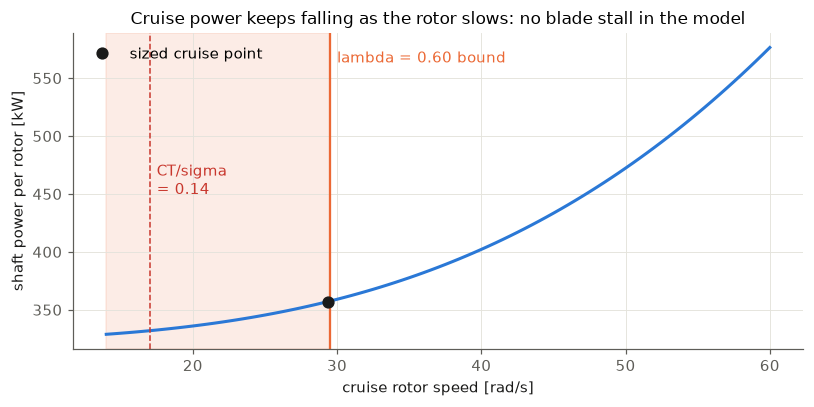

PASS  power decreases monotonically as the rotor slows, through and beyond the limits


In [8]:
speeds = np.linspace(14, 60, 93)
states = [airplane.evaluate(velocity_m_s, atm_cruise, thrust_N=thrust_cruise_N, speed_rad_s=w) for w in speeds]
power_kW = np.array([float(s.shaft_power_W) for s in states]) / 1e3
lam = np.array([float(s.advance_ratio) for s in states])
ct_sigma = np.array([float(s.blade_loading) for s in states])
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(speeds, power_kW, color=blue, lw=2)
ax.axvspan(speeds.min(), speeds[lam <= 0.6].min(), color=orange, alpha=0.12)
ax.axvline(speeds[lam <= 0.6].min(), color=orange, lw=1.5)
ax.text(speeds[lam <= 0.6].min() + 0.5, power_kW.max() * 0.995, "lambda = 0.60 bound", color=orange, va="top")
w14 = speeds[ct_sigma <= 0.14].min()
ax.axvline(w14, color=red, lw=1, ls="--"); ax.text(w14 + 0.5, 450, "CT/sigma\n= 0.14", color=red)
ax.plot(speed_rotor_cruise, cruise["power_rotors_W"] / 2e3, "o", color=ink, ms=7, label="sized cruise point")
ax.set(xlabel="cruise rotor speed [rad/s]", ylabel="shaft power per rotor [kW]",
       title="Cruise power keeps falling as the rotor slows: no blade stall in the model")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
check("power decreases monotonically as the rotor slows, through and beyond the limits",
      np.all(np.diff(power_kW) > 0))

At constant thrust, slowing the rotor cuts profile power (∝ (ΩR)³) while induced and useful power barely change. A
real blade would eventually stall as C_T/σ rises and the power would turn up, giving a true optimum. This model has
**no blade stall**, and the loading reference x = (C_T/σ)/(1 + 3λ²) even makes heavily loaded blades look lightly
loaded at high λ. So the power keeps falling, and the optimizer slows the rotor until the **λ ≤ 0.60 validity bound**
stops it (without that bound it would stop at C_T/σ = 0.14 instead). The bound was added after an early solve
exploited λ ≈ 0.83 (`docs/decisions/016`).

The README states this plainly: *the cruise rotor speed is set by the model's validity bounds, not by physics.*

## Why it is built this way

- **Rotor speed had to be visible.** An external review of the actuator-disk version said "the rotor model can't see
  rotor speed": with a constant FM, solidity, tip speed and cruise rotor speed were not trades at all. Momentum plus
  profile is the cheapest model that makes them trades. Switching took the design from 18,506 to 17,228 lb (v1.1 →
  v1.2), mostly through rotor speed and solidity choices.
- **One polar for both regimes**, referred to the mean section dynamic pressure, removed a trend in the cruise
  efficiency error and keeps the model to five constants.
- **Analytic and smooth.** It is a closed-form expression IPOPT can differentiate; a blade-element code with stall
  is not (yet) in the loop.
- **Calibrated, not assumed.** The constants come from a full-scale proprotor test with a held-out check, and the
  fit is linear least squares, so it is reproducible in one line.
- **The actuator disk is kept** as the simplest model and for the XV-15 validation path.

## What it can't do

- **No blade stall and no compressibility**: cruise rotor speed and the hover corner are set by bounds, not physics.
- **No conversion-mode or edgewise aerodynamics**: no rotor in-plane (H) force, no disc tilt in the rotor model.
  The conversion corridor (tutorial 11) adds disc tilt in the trim, not here.
- **A JVX-like blade is assumed** for the Halo rotor: the polar belongs to the JVX's twist and airfoils.
- **No twist, swirl or tip-loss terms** as separate physics (they are inside κ and the polar).
- **λ = 0.60 is slightly outside the data** (λ ≤ 0.56).

## What's next

From the README's aerodynamics and proprotor work package, in order of information per unit time:

1. Define a blade (twist, chord, airfoils) and run **XROTOR with XFOIL polars** (blade-element theory with stall)
   for hover, conversion and cruise.
2. Feed the result back as a **rotor performance map** (a smooth fit) in place of the analytic model, keeping JVX as
   the validation case. Then the cruise rotor speed comes from physics.
3. Rotor-wing interaction (download, blown wing) with OpenVSP's prop modelling in VSPAERO, and later CFD with the
   rotor modelled.
4. An airplane-mode rotor-speed schedule (`NEXT_STEPS.md`).

## Check yourself

<details><summary>1. Why can't a constant figure of merit size a proprotor?</summary>

Because it makes power independent of rotor speed, solidity and tip speed, so the optimizer has nothing to trade
(and the drive system, sized by torque = power / speed, would push the rotor to the fastest allowed speed with no
aerodynamic penalty). Momentum plus profile makes profile power ∝ σ (ΩR)³ visible.
</details>

<details><summary>2. Why is the sized hover tip speed exactly 238.2 m/s?</summary>

It is the upper bound on the design tip speed, Mach 0.70 at sea level. Faster rotors need less torque for the same
power, and torque sizes the motors and gearboxes; the model has no compressibility penalty, so the optimizer goes to
the bound, which stands for the tip Mach the JVX data supports.
</details>

<details><summary>3. What sets the cruise rotor speed, and what would fix it?</summary>

The λ ≤ 0.60 validity bound: power keeps falling as the rotor slows because the model has no blade stall. A
blade-element model with stall (XROTOR/XFOIL), brought in as a performance map, would create the real optimum.
</details>

<details><summary>4. Why is κ fixed at 1.15 rather than fitted?</summary>

Over the JVX data range the induced-power factor and the loading-dependent drag terms are collinear: a free fit
trades one for the other and returns κ < 1, which is unphysical. Fixing κ at a standard value keeps the fit
well-posed.
</details>

In [9]:
check_summary()

9 of 9 checks passed
